# Whole-brain reconstruction-autoencoder pretraining — common notebook (adapter-driven)

One model-agnostic notebook for every STATIC encoder-pretraining experiment
(GAAE, VGAE). The per-model logic lives in a **static adapter**
(`CLASSIFIER/adapters/static.py`) selected by the `ADAPTER` parameter (defaults to
`MODEL`); the SHARED cells below call only the four contract hooks plus
`common/` utilities, so they are identical across encoder architectures.

Replaces the independently-drifted `STATIC_GAAE_DELCODE_WHOLE_BRAIN.ipynb` /
`STATIC_VGAE_DELCODE_WHOLE_BRAIN.ipynb` (now archived under `notebooks/STATIC/archive/`)
with one notebook + two adapter classes — the same shape
`LONGITUDINAL_COMMON_DELCODE.ipynb` already uses for GELSTM/GEC/GEP. Driven by
`run_experiment.py` via `the experiments/ directory`; also runnable standalone
(interactive prompts preserved).

In [1]:
# === Papermill parameters (injected by run_experiment.py) ===
# Safe interactive defaults: None keeps the original Jupyter behaviour
# (interactive checkpoint prompts, JSON-config loading).
EXPERIMENT_ID = None
MODE = None
MODEL = None
ADAPTER = None                # adapter registry key; None -> defaults to MODEL
DATASET = None
SEED = 42
GAAE_CHECKPOINT_PATH = None   # None -> interactive checkpoint picker; reused here as the
                              # generic "load this checkpoint instead of training" slot.
THRESHOLD_MODE = None         # unused by STATIC pretraining (no classification threshold);
                              # kept so run_experiment.py's fixed param set injects cleanly.
FIXED_THRESHOLD = None        # unused by STATIC pretraining; see THRESHOLD_MODE above.
WANDB_ENABLED = True          # W&B logging is on by default
OUTPUT_DIR = None             # defaults to checkpoints_<model>_whole_brain/ when run standalone
RESOLVED_CONFIG = None        # merged hyperparameter dict (dataclass < json < hyperparams)
RUN_DIR = None                # set by the runner: where run_summary.json / artifacts go
RUN_NAME = None               # set by the runner: the W&B run name

In [2]:
# Parameters
EXPERIMENT_ID = "vgae-gat-static"
MODE = "static"
MODEL = "VGAE"
DATASET = "DELCODE_WHOLE_BRAIN"
SEED = 42
GAAE_CHECKPOINT_PATH = None
THRESHOLD_MODE = None
FIXED_THRESHOLD = None
WANDB_ENABLED = True
OUTPUT_DIR = "outputs/vgae-gat-static"
RESOLVED_CONFIG = {"seed": 100, "batch_size": 64, "learning_rate": 0.001, "weight_decay": 0.001, "beta": 1.0, "epochs": 500, "early_stopping_patience": 25, "latent_dim": 64, "hidden_dim": 128, "conv_type": "gat", "num_heads": 2, "dropout": 0.3, "adjacency_k": 16, "num_workers": 8, "file_variant": "z_transformed"}
RUN_DIR = "/mnt/e/fyassine/ad-early-detection/CLASSIFIER/outputs/vgae-gat-static/runs/scarlet-voice-5-4b69eede5-2026-06-23_22-47-34"
RUN_NAME = "scarlet-voice-5-4b69eede5-2026-06-23_22-47-34"
ADAPTER = "vgae"


## Pipeline overview

`set_seed` → load splits → config (`RESOLVED_CONFIG`) → checkpoint picker
(`USE_EXISTING` / `LOAD_PATH`) → `GraphDatasetInMemoryFiltered` × 3 →
`get_static_adapter(ADAPTER or MODEL)` → `build_model` (HOOK) → train-or-load
(drives `run_training` HOOK) → save checkpoint + `update_latest_checkpoint`
(`latest_checkpoint_tag` HOOK) → loss curve → cohort reconstruction-error
analysis (drives `compute_sample_error` HOOK) → robustness evaluation (noise
sweep over the same hook).

In [3]:
import sys
from pathlib import Path
repo_root = Path('/mnt/e/fyassine/ad-early-detection')
model_root = Path('/mnt/e/fyassine/ad-early-detection/CLASSIFIER')
if str(model_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
    sys.path.insert(0, str(model_root))

In [4]:
# reproducibility seeding — must run before datasets, samplers, or models.
from CLASSIFIER.common.seeding import (
    set_seed, make_rng, make_torch_generator, seed_worker,
)
set_seed(SEED)
rng = make_rng(SEED)
torch_gen = make_torch_generator(SEED)

In [5]:
import json, os, warnings
from datetime import datetime

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from torch_geometric.loader import DataLoader

# Shared, model-agnostic utilities (the lifted notebook logic — reuse, do not inline).
from common.sanity import run_full_audit
from common import tracking
from common.provenance import region_from_data_root
from common.checkpoints import update_latest_checkpoint
from common.reconstruction_eval import compute_errors_for_dataset
from adapters.static import get_static_adapter

from model.GAAE.dataset import GraphDatasetInMemoryFiltered
from model.GAAE.utils import knn_binary_adjacency_matrix_no_diag
# compute_one_vs_rest_thresholds / is_cohort_positive / plot_cohort_errors /
# plot_robustness_sweep only touch DataFrames/dicts — no GAAE coupling — so they
# are reused as-is despite living under model/GAAE/.
from model.GAAE.evaluation import (
    compute_one_vs_rest_thresholds,
    is_cohort_positive,
    plot_cohort_errors,
    plot_robustness_sweep,
)

warnings.filterwarnings('ignore')
print('Imports OK')

Imports OK


In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


## Configuration

In [7]:
from DATA.src.splitting.load_splits import splits_dir, split_csv_paths

# ── Paths ────────────────────────────────────────────────────────────────
WB_DATA_ROOT = '/mnt/e/fyassine/ad-early-detection/DATA/DELCODE/__fc_wholebrain_sch200_flat__/matrices'
METADATA_DIR = '/mnt/e/fyassine/ad-early-detection/DATA/DELCODE/__fc_wholebrain_sch200_flat__/metadata'
# STATIC pretraining trains the encoder itself on the all-cohort 'pretrain' split
# (healthy/ad/mci/converter) — never the mci/converter-only 'downstream' split.
SPLITS_DIR = str(splits_dir('pretrain'))
TRAIN_CSV  = os.path.join(SPLITS_DIR, 'train.csv')
VAL_CSV    = os.path.join(SPLITS_DIR, 'val.csv')
TEST_CSV   = os.path.join(SPLITS_DIR, 'test.csv')

DATA_INFO = region_from_data_root(WB_DATA_ROOT)
REGION    = DATA_INFO['region']
print(f"Input data: region={DATA_INFO['region']}  atlas={DATA_INFO['atlas']}  ({DATA_INFO['dataset_dir']})")

MODEL_NAME = (MODEL or 'model').lower()
CKPT_ROOT = model_root / 'notebooks' / 'checkpoints' / f'checkpoints_{MODEL_NAME}_whole_brain'
CKPT_ROOT.mkdir(parents=True, exist_ok=True)
if OUTPUT_DIR is None:
    OUTPUT_DIR = str(CKPT_ROOT)

# Training hyperparameters come entirely from the runner (RESOLVED_CONFIG = dataclass
# defaults < config_path json < hyperparams). Standalone use without a config falls
# back to each adapter's typed defaults.
CONFIG = dict(RESOLVED_CONFIG) if RESOLVED_CONFIG else {}
ADJACENCY_K    = CONFIG.get('adjacency_k', 16)
ADJACENCY_ARGS = {'k': ADJACENCY_K}
BATCH_SIZE     = CONFIG.get('batch_size', 64)
NUM_WORKERS    = CONFIG.get('num_workers', 8)
FILE_VARIANT   = CONFIG.get('file_variant', 'z_transformed')
print('Config set.  CONFIG keys:', sorted(CONFIG))

Input data: region=wholebrain  atlas=sch200  (__fc_wholebrain_sch200_flat__)
Config set.  CONFIG keys: ['adjacency_k', 'batch_size', 'beta', 'conv_type', 'dropout', 'early_stopping_patience', 'epochs', 'file_variant', 'hidden_dim', 'latent_dim', 'learning_rate', 'num_heads', 'num_workers', 'seed', 'weight_decay']


In [8]:
# split-hygiene audit — hard-fails if any subject crosses splits.
_ = run_full_audit(split_csv_paths('pretrain'))

[SANITY] Split sizes: {'train': 241, 'val': 115, 'test': 116}
[SANITY] Pairwise-disjoint: OK


## Train vs load existing checkpoint

In [9]:
_candidates = sorted(
    [
        d
        for d in CKPT_ROOT.iterdir()
        if d.is_dir() and (d / f"model_{d.name}.pth").exists()
    ],
    key=lambda d: d.name,
) if CKPT_ROOT.is_dir() else []

if _candidates:
    print(f'  0: Train a new {MODEL or "model"} (default)')
    for i, d in enumerate(_candidates, start=1):
        print(f"  {i}: {d.name}")
    if GAAE_CHECKPOINT_PATH is not None:
        _idx_str = ''   # runner supplied an explicit checkpoint (handled below)
    elif RUN_DIR is not None:
        _idx_str = '0'  # headless default: train a new model
    else:
        _idx_str = input("Select [0=train new / 1,2,...=load existing, Enter=train new]: ").strip()
    _idx = int(_idx_str) if _idx_str.isdigit() else 0
else:
    print(f'No existing {MODEL or "model"} checkpoints found — will train a new model.')
    _idx = 0

if GAAE_CHECKPOINT_PATH is not None:
    USE_EXISTING = True
    LOAD_PATH = str((model_root / GAAE_CHECKPOINT_PATH) if not os.path.isabs(GAAE_CHECKPOINT_PATH) else GAAE_CHECKPOINT_PATH)
elif 1 <= _idx <= len(_candidates):
    USE_EXISTING = True
    LOAD_PATH = str(_candidates[_idx - 1] / f"model_{_candidates[_idx - 1].name}.pth")
else:
    USE_EXISTING = False
    LOAD_PATH = None
print('USE_EXISTING =', USE_EXISTING, '| LOAD_PATH =', LOAD_PATH)

  0: Train a new VGAE (default)
  1: dapper-moon-8-vgae-gcn-static-2026-06-23_22-25-42_2026-06-23_22-27-44
  2: gentle-harbor-7-vgae-gcn-static-2026-06-23_22-24-38_2026-06-23_22-26-49
  3: solar-wildflower-5-vgae-gcn-static-2026-06-23_22-43-27_2026-06-23_22-45-00
  4: vgae-gat-static-anticollapse_2026-06-23_19-19-36
  5: vgae-gat-static_2026-06-21_21-46-27
  6: vgae-gat-static_2026-06-21_23-59-10
  7: vgae-gat-static_2026-06-23_21-21-58
  8: vgae-gcn-static-anticollapse_2026-06-23_16-47-32
  9: vgae-gcn-static-anticollapse_2026-06-23_17-09-43
  10: vgae-gcn-static-anticollapse_2026-06-23_17-31-46
  11: vgae-gcn-static-anticollapse_2026-06-23_21-12-57
  12: vgae-gcn-static_2026-06-21_19-45-45
  13: vgae-gcn-static_2026-06-21_20-08-03
  14: vgae-gcn-static_2026-06-21_23-57-00
  15: vgae-gcn-static_2026-06-23_21-17-23
USE_EXISTING = False | LOAD_PATH = None


## Dataset

In [10]:
def _make_dataset(csv_path: str):
    return GraphDatasetInMemoryFiltered(
        root=WB_DATA_ROOT,
        adjacency_function=knn_binary_adjacency_matrix_no_diag,
        adjacency_args=ADJACENCY_ARGS,
        filter_csv_path=csv_path,
        patient_info_path=csv_path,
        separator=',',
        file_variant=FILE_VARIANT,
    )

train_dataset = _make_dataset(TRAIN_CSV)
val_dataset   = _make_dataset(VAL_CSV)
test_dataset  = _make_dataset(TEST_CSV)

in_features = train_dataset[0].x.size(1)
print(f"Train: {len(train_dataset)}  Val: {len(val_dataset)}  Test: {len(test_dataset)}  in_features={in_features}")

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, worker_init_fn=seed_worker, generator=torch_gen,
    persistent_workers=NUM_WORKERS > 0, pin_memory=torch.cuda.is_available(),
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, worker_init_fn=seed_worker, generator=torch_gen,
    persistent_workers=NUM_WORKERS > 0, pin_memory=torch.cuda.is_available(),
)

DATASET_INFO = {
    'dataset_name': 'Whole-brain Schaefer kNN graph (subject-level split)',
    'kNN_param': ADJACENCY_K,
    'file_variant': FILE_VARIANT,
    'num_features': in_features,
    'train_dataset_size': len(train_dataset),
    'val_dataset_size': len(val_dataset),
    'test_dataset_size': len(test_dataset),
    'batch_size': BATCH_SIZE,
}
print(f'Dataset info: {json.dumps(DATASET_INFO, indent=2)}')

Train: 371  Val: 217  Test: 224  in_features=200
Dataset info: {
  "dataset_name": "Whole-brain Schaefer kNN graph (subject-level split)",
  "kNN_param": 16,
  "file_variant": "z_transformed",
  "num_features": 200,
  "train_dataset_size": 371,
  "val_dataset_size": 217,
  "test_dataset_size": 224,
  "batch_size": 64
}


## Model adapter

`get_static_adapter(ADAPTER or MODEL)` resolves the per-model adapter
(`CLASSIFIER/adapters/static.py`), instantiated with the merged training config,
device, and rng. Its bound methods are aliased to the contract-hook names the
SHARED cells call.

In [11]:
adapter = get_static_adapter(ADAPTER or MODEL)(cfg=CONFIG, device=device, rng=rng)
print(f'Adapter: {type(adapter).__name__}  (key={ADAPTER or MODEL})  model_tag={adapter.model_tag}')

# Bind the four contract hooks so every SHARED cell below stays model-agnostic.
build_model           = adapter.build_model
run_training          = adapter.run_training
compute_sample_error  = adapter.compute_sample_error
latest_checkpoint_tag = adapter.latest_checkpoint_tag

Adapter: VGAEStaticAdapter  (key=vgae)  model_tag=vgae


## Model

In [12]:
# HOOK: instantiate the model + return its architecture-config dict.
model, model_config = build_model(in_features)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=CONFIG.get('learning_rate', 1e-3),
    weight_decay=CONFIG.get('weight_decay', 1e-3),
)
print(f"Model: {model.__class__.__name__}  params={sum(p.numel() for p in model.parameters()):,}")
print(f"  model_config={model_config}")

Model: VariationalGraphAutoencoder  params=329,088
  model_config={'model_type': 'VariationalGraphAutoencoder', 'in_features': 200, 'hidden_dim': 128, 'latent_dim': 64, 'conv_type': 'gat', 'num_heads': 2, 'dropout': 0.3, 'beta': 1.0, 'beta_warmup_epochs': 0, 'free_bits': 0.0, 'feature_decoder': False, 'feature_loss_weight': 0.0}


## Train (or load)

In [13]:
_wb_exp = {
    'id': EXPERIMENT_ID or f'{MODEL_NAME}-static', 'mode': MODE or 'static',
    'model': MODEL or MODEL_NAME.upper(), 'dataset': DATASET or REGION,
    'seed': SEED, 'wandb': WANDB_ENABLED,
}
WANDB_RUN = tracking.init_run(_wb_exp, {**CONFIG, 'REGION': REGION, 'adapter': ADAPTER or MODEL, 'RUN_NAME': RUN_NAME})

if USE_EXISTING:
    obj = torch.load(LOAD_PATH, map_location=device, weights_only=False)
    if isinstance(obj, torch.nn.Module):
        model = obj.to(device)
    else:
        model.load_state_dict(obj.get('model_state_dict', obj))
        model = model.to(device)
    best_model = model
    history = {'train_loss': [], 'val_loss': []}
    run_name = RUN_NAME or f'loaded_{datetime.now().strftime("%Y-%m-%d_%H-%M-%S")}'
    run_dir = CKPT_ROOT / run_name
    print(f'Loaded checkpoint from {LOAD_PATH} — training skipped.')
else:
    # HOOK: train one model to convergence.
    best_state, history = run_training(model, optimizer, train_loader, val_loader, WANDB_RUN)
    model.load_state_dict(best_state)
    best_model = model

    ts = datetime.now().strftime('%Y-%m-%d_%H-%M-%S')
    try:
        wname = WANDB_RUN.name if WANDB_RUN and getattr(WANDB_RUN, 'name', None) else f'{MODEL_NAME}-static'
    except Exception:
        wname = f'{MODEL_NAME}-static'
    run_name = f'{str(wname).replace(" ", "-")}_{ts}'
    run_dir = CKPT_ROOT / run_name
    run_dir.mkdir(parents=True, exist_ok=True)

    # Plain-module save — the convention both GAAE and VGAE checkpoints already use.
    torch.save(best_model, run_dir / f'model_{run_name}.pth')

    def _json_serial(obj):
        if isinstance(obj, (datetime, torch.device)):
            return str(obj)
        raise TypeError(f'Type {type(obj)} not serializable')

    (run_dir / 'run_config.json').write_text(json.dumps({
        'run_name': run_name, 'timestamp': ts,
        'dataset_info': DATASET_INFO, 'model_config': model_config,
        'training_config': CONFIG,
    }, indent=2, default=_json_serial))
    (run_dir / 'history.json').write_text(json.dumps(history, indent=2))

    # HOOK: tag for the "latest checkpoint" symlink consumed by downstream notebooks.
    latest_path = update_latest_checkpoint(
        CKPT_ROOT, latest_checkpoint_tag(), run_dir / f'model_{run_name}.pth'
    )
    print(f'Updated latest checkpoint pointer: {latest_path}')
    print(f'Saved checkpoint to {run_dir / f"model_{run_name}.pth"}')

VGAE Training:   0%|          | 0/500 [00:00<?, ?it/s]

Updated latest checkpoint pointer: /mnt/e/fyassine/ad-early-detection/CLASSIFIER/notebooks/checkpoints/checkpoints_vgae_whole_brain/VGAE_GAT.pth
Saved checkpoint to /mnt/e/fyassine/ad-early-detection/CLASSIFIER/notebooks/checkpoints/checkpoints_vgae_whole_brain/scarlet-voice-5-vgae-gat-static-2026-06-23_22-47-34_2026-06-23_22-49-41/model_scarlet-voice-5-vgae-gat-static-2026-06-23_22-47-34_2026-06-23_22-49-41.pth


In [14]:
# Runner ledger: write a run_summary.json into RUN_DIR when launched by run_experiment.py.
if RUN_DIR:
    best_val = min(history['val_loss']) if history.get('val_loss') else None
    summary = {
        'experiment_id': EXPERIMENT_ID, 'timestamp': datetime.now().isoformat(timespec='seconds'),
        'model_config': model_config, 'training_config': CONFIG,
        'checkpoint': str(run_dir / f'model_{run_name}.pth'),
        'metrics': {'best_val_loss': best_val},
    }
    (Path(RUN_DIR) / 'run_summary.json').write_text(json.dumps(summary, indent=2, default=str))
    print('Wrote', Path(RUN_DIR) / 'run_summary.json')
try:
    tracking.finish_run(WANDB_RUN)
except NameError:
    pass

Wrote /mnt/e/fyassine/ad-early-detection/CLASSIFIER/outputs/vgae-gat-static/runs/scarlet-voice-5-4b69eede5-2026-06-23_22-47-34/run_summary.json


## Training curve

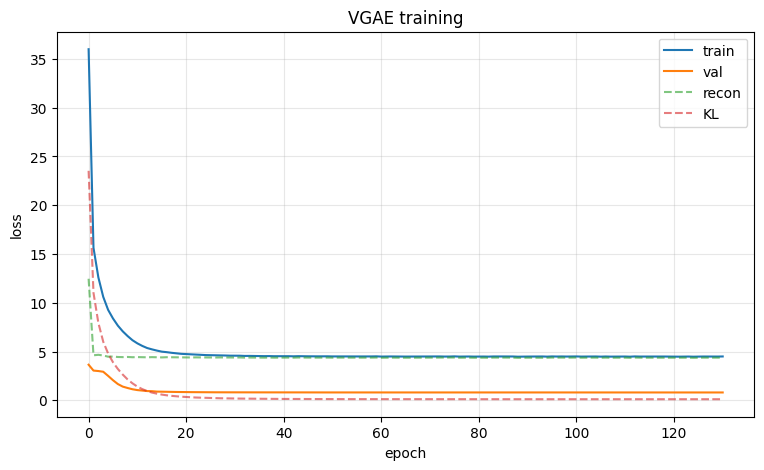

In [15]:
if history.get('train_loss'):
    plt.figure(figsize=(9, 5))
    plt.plot(history['train_loss'], label='train')
    plt.plot(history['val_loss'], label='val')
    if history.get('train_recon'):
        plt.plot(history['train_recon'], '--', label='recon', alpha=0.6)
    if history.get('train_kl'):
        plt.plot(history['train_kl'], '--', label='KL', alpha=0.6)
    plt.xlabel('epoch'); plt.ylabel('loss')
    plt.title(f'{MODEL or "Model"} training'); plt.legend(); plt.grid(alpha=0.3)
    plt.show()
else:
    print('No training-loss history available for this run — skipping plot.')

## Cohort Reconstruction-Error Analysis

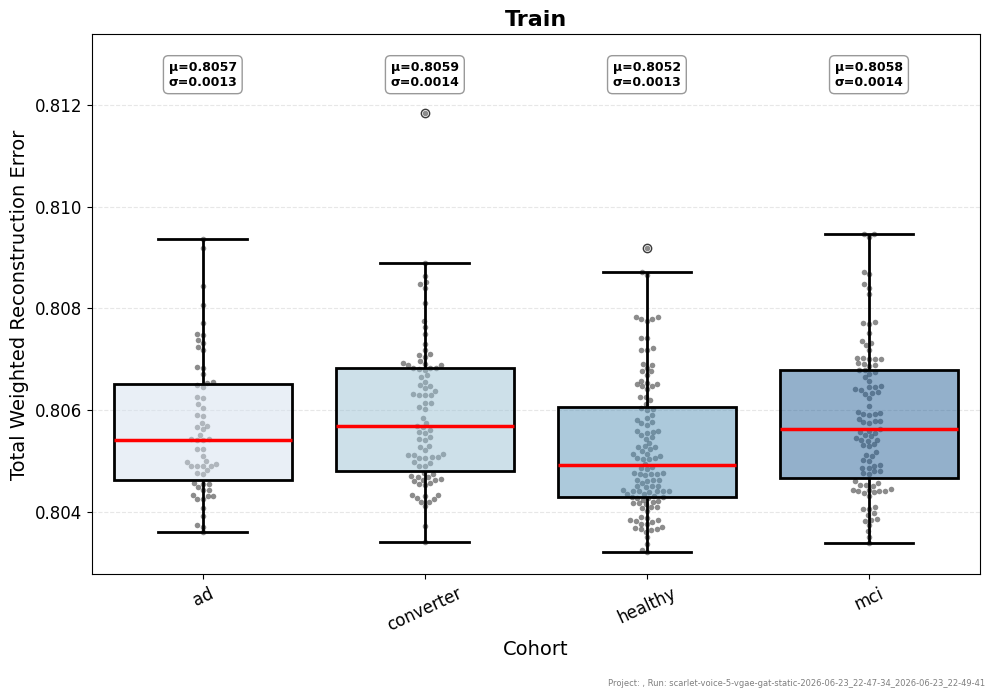

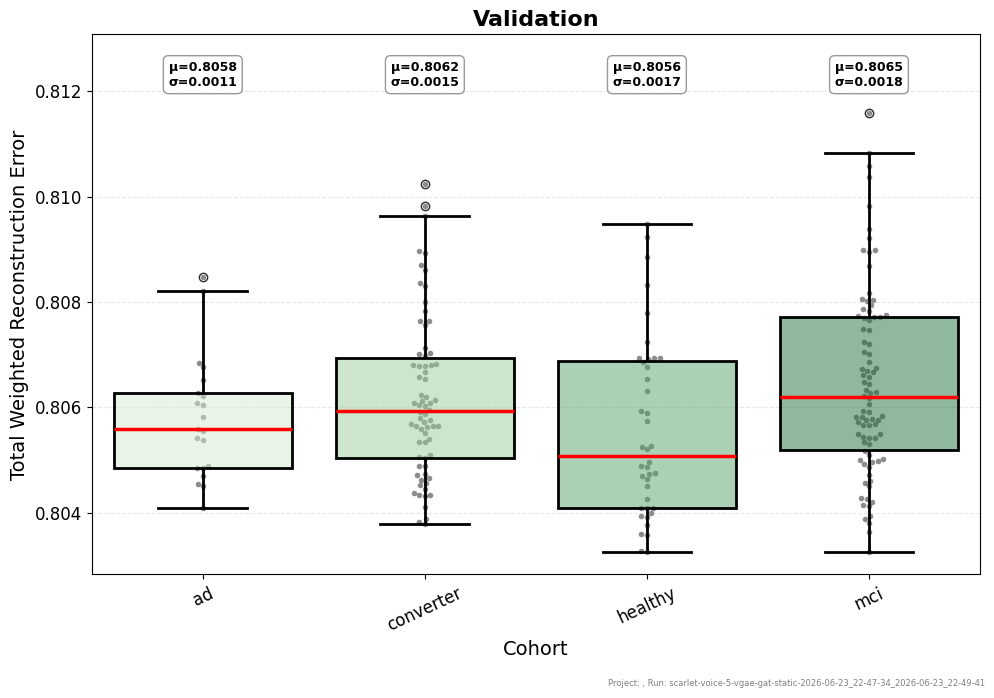

Train cohort counts:
Cohort
ad            62
converter     86
healthy      120
mci          103
dtype: int64

Validation cohort counts:
Cohort
ad           21
converter    70
healthy      40
mci          86
dtype: int64


In [16]:
eval_model = best_model.to(device)
eval_model.eval()

train_split_df = pd.read_csv(TRAIN_CSV)
val_split_df   = pd.read_csv(VAL_CSV)
assert 'Pseudonym' in train_split_df.columns and 'diagnosis' in train_split_df.columns
assert 'Pseudonym' in val_split_df.columns   and 'diagnosis' in val_split_df.columns

allowed_cohorts = {'ad', 'converter', 'healthy', 'mci'}

combined_split_df = pd.concat([train_split_df, val_split_df], ignore_index=True)
subject_cohort_map = (
    combined_split_df[['Pseudonym', 'diagnosis']]
    .drop_duplicates(subset=['Pseudonym'], keep='first')
    .assign(
        Pseudonym=lambda d: d['Pseudonym'].astype(str).str.strip(),
        diagnosis=lambda d: d['diagnosis'].astype(str).str.lower().str.strip(),
    )
    .set_index('Pseudonym')['diagnosis']
    .to_dict()
)

# HOOK call wrapped as an error_fn closure for compute_errors_for_dataset.
def _error_fn(sample):
    return compute_sample_error(sample, eval_model)

train_errors_df = compute_errors_for_dataset(
    train_dataset, 'Train', _error_fn, subject_cohort_map, allowed_cohorts=allowed_cohorts,
)
val_errors_df = compute_errors_for_dataset(
    val_dataset, 'Validation', _error_fn, subject_cohort_map, allowed_cohorts=allowed_cohorts,
)

cohort_order = [
    c for c in ['ad', 'converter', 'healthy', 'mci']
    if c in set(train_errors_df['Cohort']) | set(val_errors_df['Cohort'])
]

for _split_name, _split_df, _palette in [
    ('Train', train_errors_df, 'Blues'),
    ('Validation', val_errors_df, 'Greens'),
]:
    plot_cohort_errors(_split_name, _split_df, cohort_order, _palette, '', run_name)

print('Train cohort counts:')
print(train_errors_df.groupby('Cohort').size().sort_index())
print('\nValidation cohort counts:')
print(val_errors_df.groupby('Cohort').size().sort_index())

## Robustness Evaluation (Threshold from Reconstruction Error)

Validation one-vs-rest thresholds:
   Cohort Direction      AUC  ThresholdError
  healthy       low 0.629096        0.805274
       ad       low 0.556365        0.806842
      mci      high 0.587342        0.807015
converter      high 0.515743        0.804314



Selected samples per cohort:
SelectionCohort
ad           5
converter    5
healthy      5
mci          5



Cohort stability summary:
SelectionCohort               Method  NoiseLevelPercent  CohortStabilityRate
             ad   conditioning_noise                0.0                 1.00
             ad   conditioning_noise                5.0                 1.00
             ad   conditioning_noise               10.0                 1.00
             ad   conditioning_noise               20.0                 1.00
             ad   conditioning_noise               30.0                 1.00
             ad    edge_perturbation                0.0                 1.00
             ad    edge_perturbation                5.0                 1.00
             ad    edge_perturbation               10.0                 1.00
             ad    edge_perturbation               20.0                 1.00
             ad    edge_perturbation               30.0                 1.00
             ad        feature_noise                0.0                 1.00
             ad        feature_noise             

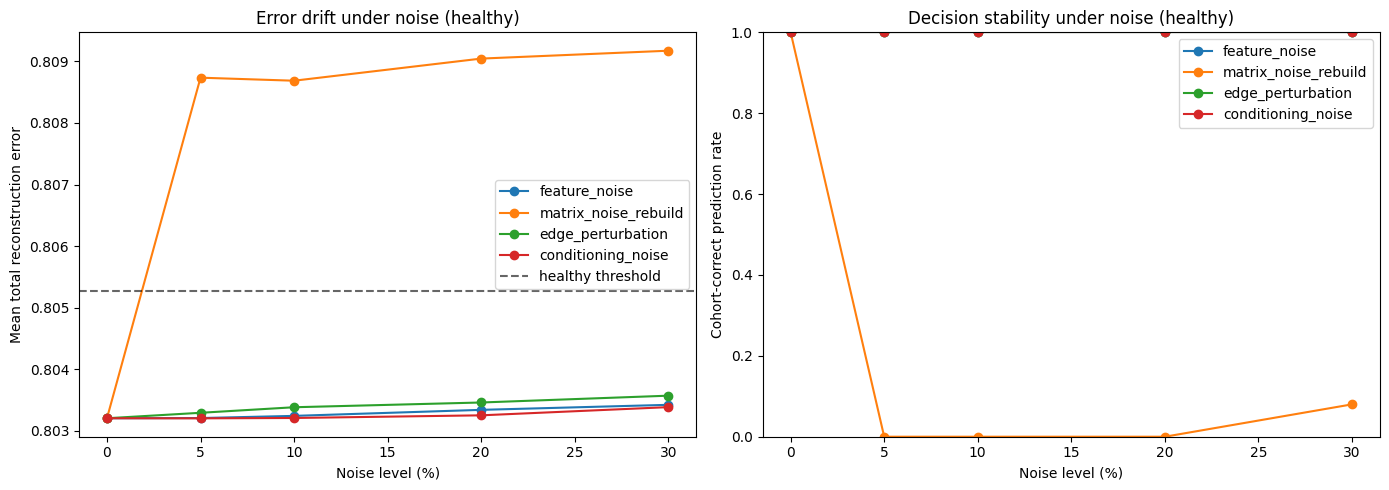

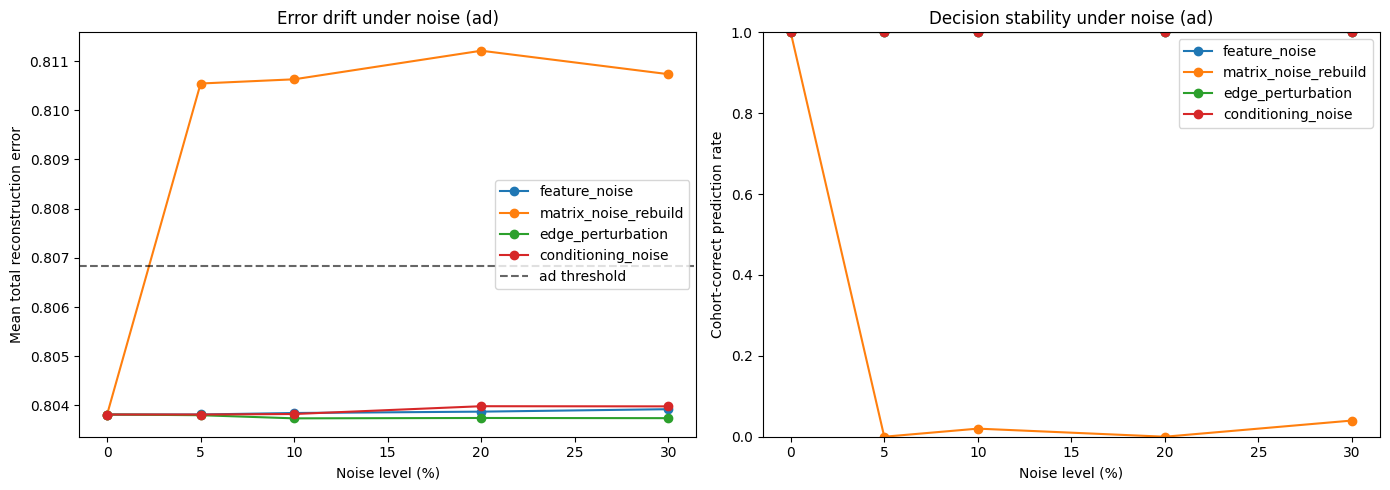

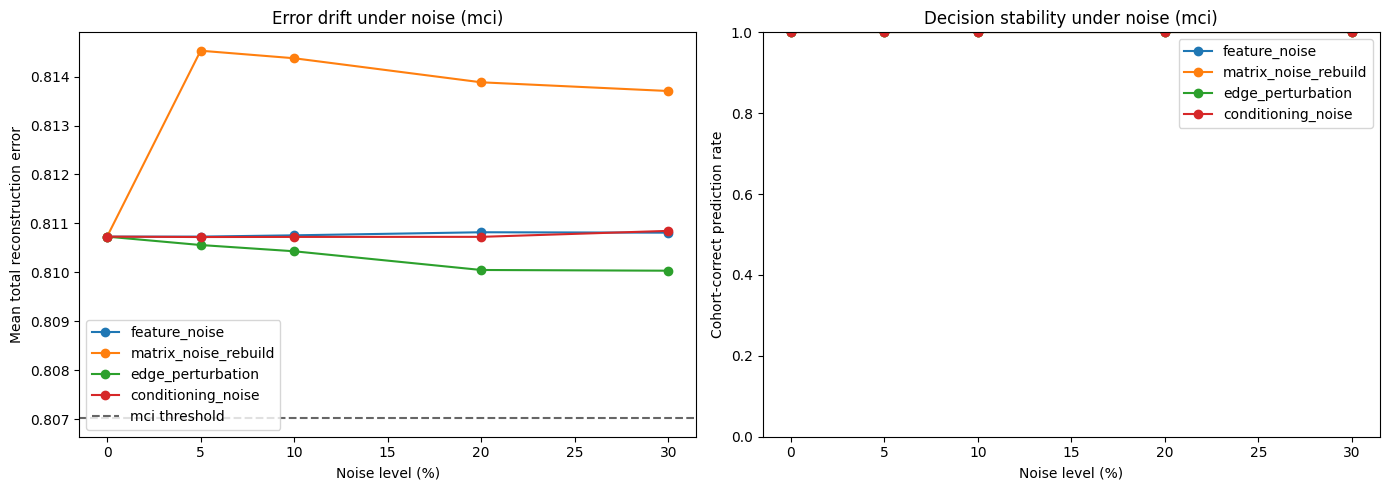

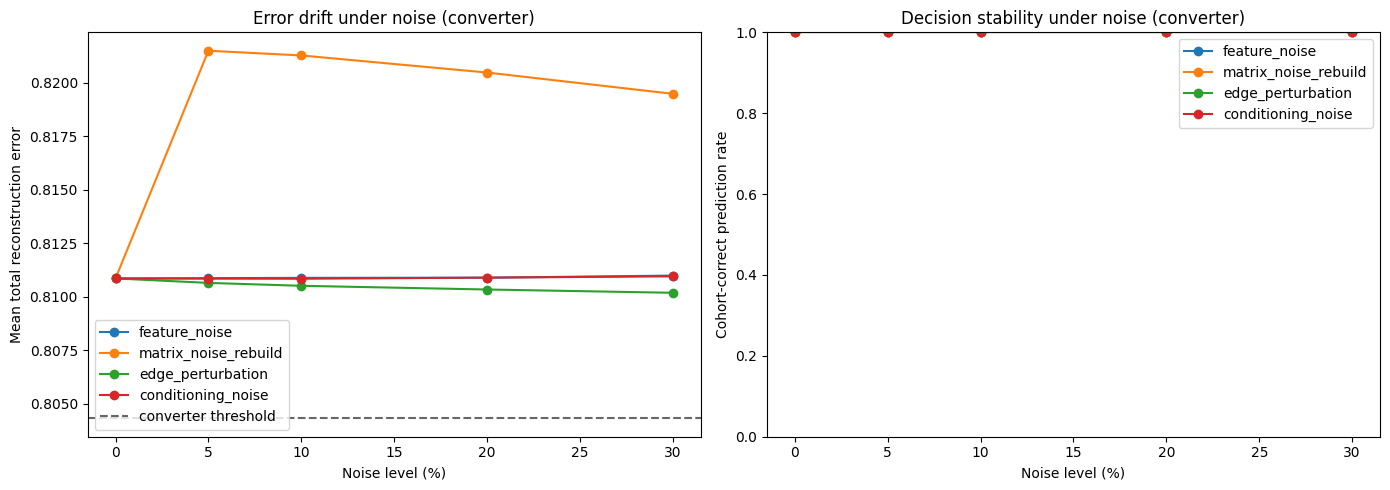

Saved evaluation artifacts to: /mnt/e/fyassine/ad-early-detection/CLASSIFIER/notebooks/checkpoints/checkpoints_vgae_whole_brain/scarlet-voice-5-vgae-gat-static-2026-06-23_22-47-34_2026-06-23_22-49-41/robustness_eval_2026-06-23_22-50-25


In [17]:
if 'val_errors_df' not in globals():
    raise RuntimeError('val_errors_df missing — run the cohort-error cell first.')

# ── Build full cohort map (train + val + test) ────────────────────────────
subject_cohort_map_all = dict(subject_cohort_map)
subject_cohort_map_all.update(
    pd.read_csv(TEST_CSV)[['Pseudonym', 'diagnosis']]
    .dropna()
    .drop_duplicates(subset=['Pseudonym'])
    .assign(
        Pseudonym=lambda d: d['Pseudonym'].astype(str),
        diagnosis=lambda d: d['diagnosis'].astype(str).str.lower().str.strip(),
    )
    .set_index('Pseudonym')['diagnosis']
    .to_dict()
)

# ── Val-derived thresholds ────────────────────────────────────────────────
cohorts_to_analyze = ['healthy', 'ad', 'mci', 'converter']
cohort_thresholds  = compute_one_vs_rest_thresholds(val_errors_df, cohorts_to_analyze)

threshold_rows = [
    {'Cohort': c, 'Direction': cohort_thresholds[c]['direction'],
     'AUC': cohort_thresholds[c]['auc'], 'ThresholdError': cohort_thresholds[c]['threshold_error']}
    for c in cohorts_to_analyze
]
print('Validation one-vs-rest thresholds:')
print(pd.DataFrame(threshold_rows).to_string(index=False))

# ── Test errors + cohort predictions ─────────────────────────────────────
test_errors_eval_df = compute_errors_for_dataset(
    test_dataset, 'Test', _error_fn, subject_cohort_map_all,
)
for c in cohorts_to_analyze:
    test_errors_eval_df[f'Pred_{c}'] = test_errors_eval_df['Total Error'].apply(
        lambda e: is_cohort_positive(float(e), cohort_thresholds[c])
    )

# ── Top-k selection ───────────────────────────────────────────────────────
top_k = 5
selected_frames = []
for cohort_name in cohorts_to_analyze:
    th = cohort_thresholds[cohort_name]
    if np.isnan(th['threshold_error']):
        print(f'Skipping {cohort_name}: threshold is NaN.')
        continue
    candidates = test_errors_eval_df[
        (test_errors_eval_df['Cohort'] == cohort_name) &
        (test_errors_eval_df[f'Pred_{cohort_name}'] == 1)
    ].copy()
    candidates['SelectionMargin'] = (
        candidates['Total Error'] - th['threshold_error'] if th['direction'] == 'high'
        else th['threshold_error'] - candidates['Total Error']
    )
    if candidates.empty:
        print(f'No eligible samples for cohort={cohort_name}.')
        continue
    top = candidates.sort_values('SelectionMargin', ascending=False).head(top_k).copy()
    top['SelectionCohort'] = cohort_name
    selected_frames.append(top)

if not selected_frames:
    raise RuntimeError('No selected samples found for any cohort.')
selected_samples_df = pd.concat(selected_frames, ignore_index=True)
print('\nSelected samples per cohort:')
print(selected_samples_df.groupby('SelectionCohort').size().sort_index().to_string())

# ── Robustness sweep — noise sweep delegates to compute_errors_for_dataset,
# scoped to one selected subject at a time per cohort/method/noise-level/trial. ─
noise_levels  = [0.00, 0.05, 0.10, 0.20, 0.30]
n_trials      = 10
noise_methods = ['feature_noise', 'matrix_noise_rebuild', 'edge_perturbation', 'conditioning_noise']

records = []
for _, row in selected_samples_df.iterrows():
    ds_idx     = int(row['DatasetIndex'])
    patient_id = str(row['PatientID'])
    sel_cohort = str(row['SelectionCohort'])
    cohort_thr = cohort_thresholds[sel_cohort]
    single_ds  = [test_dataset[ds_idx]]

    for method in noise_methods:
        for noise_level in noise_levels:
            for trial in range(n_trials):
                err_df = compute_errors_for_dataset(
                    single_ds, 'Robustness', _error_fn, {patient_id: sel_cohort},
                    noise_method=method, noise_level=noise_level, rng=rng,
                    adjacency_args=ADJACENCY_ARGS,
                )
                total_err = float(err_df['Total Error'].iloc[0])
                records.append({
                    'SelectionCohort': sel_cohort, 'PatientID': patient_id,
                    'DatasetIndex': ds_idx, 'Method': method,
                    'NoiseLevel': noise_level, 'NoiseLevelPercent': noise_level * 100.0,
                    'Trial': trial, 'Total Error': total_err,
                    'CohortStable': is_cohort_positive(total_err, cohort_thr),
                })

robustness_df = pd.DataFrame(records)
summary_df = (
    robustness_df
    .groupby(['SelectionCohort', 'Method', 'NoiseLevel', 'NoiseLevelPercent'], as_index=False)
    .agg(MeanTotalError=('Total Error', 'mean'), StdTotalError=('Total Error', 'std'),
         CohortStabilityRate=('CohortStable', 'mean'))
)
print('\nCohort stability summary:')
print(
    summary_df[['SelectionCohort', 'Method', 'NoiseLevelPercent', 'CohortStabilityRate']]
    .sort_values(['SelectionCohort', 'Method', 'NoiseLevelPercent'])
    .to_string(index=False)
)

plot_robustness_sweep(summary_df, cohorts_to_analyze, cohort_thresholds, noise_methods)

# ── Save artifacts ────────────────────────────────────────────────────────
eval_dir = run_dir / f'robustness_eval_{datetime.now().strftime("%Y-%m-%d_%H-%M-%S")}'
eval_dir.mkdir(parents=True, exist_ok=True)

selected_samples_df.to_csv(eval_dir / 'selected_top5_by_cohort.csv', index=False)
summary_df.to_csv(eval_dir / 'robustness_summary_by_cohort.csv', index=False)
robustness_df.to_csv(eval_dir / 'robustness_details_by_cohort.csv', index=False)
pd.DataFrame(threshold_rows).to_csv(eval_dir / 'cohort_thresholds.csv', index=False)

with open(eval_dir / 'robustness_meta.json', 'w') as f:
    json.dump({
        'threshold_type': 'one_vs_rest_per_cohort_from_validation_reconstruction_error',
        'cohort_thresholds': cohort_thresholds,
        'noise_levels': noise_levels, 'noise_levels_percent': [x * 100.0 for x in noise_levels],
        'n_trials': n_trials, 'methods': noise_methods,
        'cohorts_to_analyze': cohorts_to_analyze, 'top_k_per_cohort': top_k,
        'selected_count_by_cohort': selected_samples_df.groupby('SelectionCohort').size().to_dict(),
    }, f, indent=2)
print(f'Saved evaluation artifacts to: {eval_dir}')